In [22]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from tqdm import tqdm

import torch
import torch.nn.functional as F

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [23]:
sensor = [22, 26, 28, 38, 55, 58, 65, 70, 75, 79, 92, 102, 109, 114, 119, 128, 147, 148, 153, 164, 190, 195, 205, 206, 210, 211, 244, 252, 286, 303, 306, 313, 317, 327, 332, 339, 359, 372, 389, 390, 391, 392, 393, 394, 395]

In [24]:
len(sensor)

45

In [25]:
# csv_url_p1="Head.csv"
# csv_url_p2="flow1.csv"
datap1 = pd.read_csv('P_quality_gt1.csv')
#datap2 = pd.read_csv('P_quality_lt1.csv')
datap_k1 = datap1.iloc[1:,1:]
datap_k1

,J511,J411,J414,J415,J416,J417,J418,J419,J310,J311,...,J317,J323,R1,T3,T1,T7,T6,T5,T2,T4
1,30.377136,65.563950,34.832300,86.600270,101.473120,30.047972,29.172054,25.540741,54.752983,50.656060,...,69.923460,69.923460,-0.000001,3.513322,2.818868,2.994066,5.463629,1.559531,0.728704,2.755558
2,30.984774,65.565380,34.979256,87.206210,102.138680,30.239360,29.384306,25.767653,56.856640,52.759140,...,74.713740,74.713740,-0.000001,4.048583,2.696090,3.968574,5.499999,2.215323,0.969480,3.352154
3,31.744596,65.848580,35.288322,89.095020,104.278595,30.543621,29.683752,26.048409,53.691456,49.587390,...,61.343662,61.343662,-0.000001,4.603395,2.617192,4.583615,5.452951,2.903393,1.202936,3.963001
4,31.385159,66.452090,36.976112,69.683266,92.083270,32.592120,31.910147,27.865423,52.882854,48.779580,...,60.581130,60.581130,-0.000001,5.187452,2.697759,3.722244,5.251726,3.750922,1.583545,4.233551
5,30.674273,68.020386,39.318940,68.957790,91.357790,35.201450,34.652145,30.163881,52.085570,47.982094,...,59.813553,59.813553,-0.000001,5.150339,2.973012,2.881570,5.020122,3.755406,2.408913,3.521921
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5372,31.076563,66.204285,37.071110,85.146640,99.252240,32.859577,32.273132,28.675858,53.191235,49.115345,...,66.998140,66.998140,-0.000001,3.456163,3.544396,2.763187,5.417325,3.907387,3.558941,3.658201
5373,31.005732,66.483986,37.363777,84.982666,99.015830,33.163918,32.585110,29.001963,53.731045,49.652150,...,70.048040,70.048040,-0.000001,3.068503,3.486055,2.733114,5.499999,3.414673,3.914947,3.596000
5374,30.792479,66.142280,36.740090,84.099190,98.163050,32.461970,31.848015,28.451643,53.207336,49.144090,...,67.472150,67.472150,-0.000001,3.344523,3.434226,2.954664,5.499999,2.443932,3.955284,3.452316
5375,30.484478,66.131950,36.732925,84.470116,98.591170,32.449840,31.832180,28.432844,53.381737,49.307360,...,69.373924,69.373924,-0.000001,3.768330,3.328512,2.546372,5.499999,1.515654,3.933369,3.066655


In [26]:
from sklearn.preprocessing import MinMaxScaler

scaler_k1 = MinMaxScaler()
# transform data
datap_k11 = scaler_k1.fit_transform(datap_k1)
datap_k11=pd.DataFrame(datap_k11)
#datap_k11.columns = datap_k1.columns
datap_k11

,0,1,2,3,4,5,6,7,8,9,...,386,387,388,389,390,391,392,393,394,395
0,0.427274,0.331072,0.117816,0.600416,0.643695,0.082845,0.429051,0.363490,0.658809,0.658163,...,0.657616,0.657616,0.0,0.223093,0.500933,0.393998,0.941343,0.023816,0.113252,0.302228
1,0.607374,0.331180,0.126984,0.613396,0.664591,0.093881,0.445627,0.384992,0.839657,0.839423,...,0.851704,0.851704,0.0,0.455866,0.473894,0.721287,1.000000,0.286423,0.157999,0.540909
2,0.832581,0.352651,0.146264,0.653857,0.731777,0.111426,0.469013,0.411597,0.567551,0.566056,...,0.309989,0.309989,0.0,0.697141,0.456519,0.927848,0.924122,0.561955,0.201386,0.785292
3,0.726046,0.398406,0.251556,0.238035,0.348885,0.229550,0.642887,0.583776,0.498037,0.496433,...,0.279093,0.279093,0.0,0.951135,0.474262,0.638557,0.599589,0.901341,0.272121,0.893531
4,0.515344,0.517306,0.397711,0.222495,0.326108,0.380013,0.857028,0.801577,0.429496,0.427699,...,0.247993,0.247993,0.0,0.934995,0.534880,0.356217,0.226061,0.903136,0.425513,0.608828
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5371,0.634580,0.379619,0.257482,0.569278,0.573967,0.244972,0.671235,0.660572,0.524548,0.525372,...,0.539091,0.539091,0.0,0.198236,0.660713,0.316457,0.866665,0.963996,0.639242,0.663350
5372,0.613586,0.400824,0.275740,0.565766,0.566544,0.262521,0.695599,0.691474,0.570955,0.571638,...,0.662664,0.662664,0.0,0.029651,0.647865,0.306358,1.000000,0.766693,0.705405,0.638465
5373,0.550379,0.374918,0.236832,0.546840,0.539770,0.222045,0.638035,0.639326,0.525932,0.527849,...,0.558297,0.558297,0.0,0.149686,0.636451,0.380765,1.000000,0.377968,0.712901,0.580981
5374,0.459090,0.374135,0.236385,0.554786,0.553211,0.221345,0.636798,0.637544,0.540925,0.541921,...,0.635351,0.635351,0.0,0.333990,0.613170,0.243640,1.000000,0.006246,0.708829,0.426689


In [27]:
datap_k12 = datap_k11.filter(sensor,axis=1)
datap_k12

,22,26,28,38,55,58,65,70,75,79,...,339,359,372,389,390,391,392,393,394,395
0,0.396555,0.078001,0.350276,0.657840,0.779299,0.559452,0.383252,0.320389,0.223774,0.300280,...,0.594738,0.0,0.389105,0.223093,0.500933,0.393998,0.941343,0.023816,0.113252,0.302228
1,0.391587,0.089283,0.352656,0.841062,0.811009,0.661064,0.388634,0.320976,0.242852,0.309996,...,0.708486,0.0,0.406757,0.455866,0.473894,0.721287,1.000000,0.286423,0.157999,0.540909
2,0.405825,0.106560,0.424729,0.532475,0.928522,0.863189,0.423571,0.342512,0.526738,0.480964,...,0.899181,0.0,0.430696,0.697141,0.456519,0.927848,0.924122,0.561955,0.201386,0.785292
3,0.436684,0.226452,0.459609,0.468627,0.638908,0.950429,0.488546,0.391109,0.547283,0.506387,...,0.801431,0.0,0.634588,0.951135,0.474262,0.638557,0.599589,0.901341,0.272121,0.893531
4,0.575046,0.377537,0.605393,0.405478,0.606746,0.554368,0.583178,0.511299,0.767475,0.692570,...,0.684003,0.0,0.855966,0.934995,0.534880,0.356217,0.226061,0.903136,0.425513,0.608828
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5371,0.457908,0.243292,0.379352,0.523465,0.569472,0.716496,0.355754,0.372818,0.223707,0.315878,...,0.465670,0.0,0.657836,0.198236,0.660713,0.316457,0.866665,0.963996,0.639242,0.663350
5372,0.486220,0.260764,0.469561,0.580652,0.543204,0.198321,0.340604,0.393824,0.575802,0.533422,...,0.421730,0.0,0.681905,0.029651,0.647865,0.306358,1.000000,0.766693,0.705405,0.638465
5373,0.467197,0.220107,0.442710,0.526269,0.466096,0.098126,0.242099,0.367105,0.554335,0.510219,...,0.285666,0.0,0.598676,0.149686,0.636451,0.380765,1.000000,0.377968,0.712901,0.580981
5374,0.462108,0.219360,0.442869,0.551155,0.537624,0.019163,0.271268,0.366403,0.557804,0.511150,...,0.360137,0.0,0.598180,0.333990,0.613170,0.243640,1.000000,0.006246,0.708829,0.426689


In [28]:
#csv_url_m1="Pattern_32.csv"
#csv_url_m2="Pattern_32_1.csv"
dataY = pd.read_csv('patt_quality_gt1.csv')
#dataY2 = pd.read_csv(csv_url_m2)
#dataY= pd.concat([dataY1.iloc[:,1:], dataY2.iloc[:,1:]], ignore_index=True, axis=1)
# datap_k222 = datap_k2.copy(deep=True)
# datap_k222.drop([5376,10753], axis=0, inplace=True)
# datap_k222.drop(sensor_no, axis=1, inplace=True)
dataY = dataY.iloc[:,1:]
dataY

,0,1,2,3,4,5,6,7,8,9,...,5366,5367,5368,5369,5370,5371,5372,5373,5374,5375
0,0.584836,0.454694,0.433095,0.338027,0.310576,0.322725,0.420209,0.454502,0.507552,0.587639,...,0.594090,0.608435,0.593578,0.665773,0.635262,0.705950,0.779173,0.821903,0.941212,0.810422
1,0.564130,0.453078,0.452341,0.352076,0.306890,0.325615,0.384138,0.488006,0.551391,0.689672,...,0.561997,0.577994,0.568410,0.622985,0.571199,0.774500,0.696642,0.788714,0.901753,0.869485
2,0.573436,0.448752,0.444788,0.363562,0.310624,0.329966,0.371491,0.467190,0.552732,0.680460,...,0.565490,0.572809,0.588063,0.630818,0.556321,0.754910,0.712469,0.786997,0.902549,0.848312
3,0.573661,0.476746,0.444334,0.346391,0.313613,0.336360,0.387514,0.489071,0.543683,0.682099,...,0.557045,0.581509,0.584161,0.627467,0.559748,0.767063,0.712153,0.773191,0.899085,0.856548
4,0.522941,0.459581,0.448544,0.299940,0.321026,0.315678,0.430518,0.420152,0.560071,0.661063,...,0.645605,0.617688,0.655696,0.655619,0.642344,0.710192,0.771353,0.733948,0.914571,0.789722
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
329,0.624550,0.449848,0.425922,0.340974,0.313991,0.305652,0.424439,0.439984,0.502905,0.572938,...,0.567673,0.605814,0.588476,0.648100,0.627491,0.694501,0.784005,0.802225,0.932128,0.782922
330,0.619272,0.452124,0.431054,0.334791,0.325762,0.318850,0.420226,0.440753,0.494284,0.584454,...,0.587910,0.604921,0.600370,0.651076,0.625531,0.684377,0.793366,0.824657,0.925223,0.804903
331,0.512911,0.455989,0.434424,0.316924,0.332877,0.324478,0.407116,0.412746,0.579417,0.668103,...,0.633697,0.602581,0.654317,0.652691,0.630110,0.705609,0.773198,0.731680,0.930475,0.776493
332,0.538453,0.455966,0.448756,0.304988,0.328337,0.316940,0.427100,0.426040,0.572210,0.674750,...,0.647163,0.620820,0.670858,0.638856,0.622502,0.707162,0.777563,0.766624,0.936825,0.764652


In [29]:
#dataY = dataY.iloc[:,1:]
dataY1 = dataY.T
dataY1

,0,1,2,3,4,5,6,7,8,9,...,324,325,326,327,328,329,330,331,332,333
0,0.584836,0.564130,0.573436,0.573661,0.522941,0.521661,0.522642,0.531658,0.560547,0.575281,...,0.624973,0.626318,0.606580,0.631619,0.613636,0.624550,0.619272,0.512911,0.538453,0.620192
1,0.454694,0.453078,0.448752,0.476746,0.459581,0.437481,0.446478,0.439240,0.455268,0.455355,...,0.462314,0.447872,0.449919,0.445038,0.424031,0.449848,0.452124,0.455989,0.455966,0.460563
2,0.433095,0.452341,0.444788,0.444334,0.448544,0.456073,0.438699,0.430503,0.447621,0.436428,...,0.445619,0.458032,0.452907,0.462321,0.432072,0.425922,0.431054,0.434424,0.448756,0.441882
3,0.338027,0.352076,0.363562,0.346391,0.299940,0.307718,0.309674,0.331859,0.360877,0.350783,...,0.349245,0.339302,0.335726,0.322526,0.338111,0.340974,0.334791,0.316924,0.304988,0.328430
4,0.310576,0.306890,0.310624,0.313613,0.321026,0.310348,0.331922,0.314965,0.311239,0.310450,...,0.298969,0.314166,0.330627,0.314721,0.309478,0.313991,0.325762,0.332877,0.328337,0.330271
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5371,0.705950,0.774500,0.754910,0.767063,0.710192,0.703990,0.701846,0.710178,0.769802,0.768021,...,0.701121,0.686359,0.681971,0.703736,0.704592,0.694501,0.684377,0.705609,0.707162,0.699330
5372,0.779173,0.696642,0.712469,0.712153,0.771353,0.785048,0.786789,0.773875,0.715942,0.705762,...,0.783239,0.782245,0.790647,0.764028,0.774542,0.784005,0.793366,0.773198,0.777563,0.789879
5373,0.821903,0.788714,0.786997,0.773191,0.733948,0.768720,0.748798,0.741301,0.767307,0.784803,...,0.819017,0.816983,0.833985,0.830456,0.808911,0.802225,0.824657,0.731680,0.766624,0.811571
5374,0.941212,0.901753,0.902549,0.899085,0.914571,0.920749,0.942879,0.932156,0.912118,0.897335,...,0.931603,0.897308,0.934156,0.931821,0.945875,0.932128,0.925223,0.930475,0.936825,0.936461


In [30]:
# from sklearn.preprocessing import MinMaxScaler

# scaler_y = MinMaxScaler()
# # transform data
# dataY = scaler_y.fit_transform(dataY)
# dataY=pd.DataFrame(dataY)

# dataY

In [31]:
dataY1.shape

(5376, 334)

In [32]:
import sklearn

In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(datap_k12,dataY1, test_size=0.2,shuffle=True)

np.shape(X_test)

(1076, 45)

In [34]:
# from sklearn.ensemble import RandomForestRegressor
# regr1 = RandomForestRegressor(n_estimators=1500, criterion='squared_error', max_depth=None, min_samples_split=2, min_samples_leaf=1, min_weight_fraction_leaf=0.0, max_features=1.0, max_leaf_nodes=None, min_impurity_decrease=0.0, bootstrap=True, oob_score=False, n_jobs=None, random_state=None, verbose=1, warm_start=False, ccp_alpha=0.0, max_samples=None)

In [41]:
from sklearn.neural_network import MLPRegressor

regr = MLPRegressor(hidden_layer_sizes=(128,128,128), activation='relu', solver='adam', alpha=0.00001, batch_size='auto', learning_rate='adaptive', learning_rate_init=0.001, power_t=0.5, max_iter=20000, shuffle=True, random_state=None, tol=0.000000000001, verbose=True, warm_start=False, momentum=0.9, nesterovs_momentum=True, early_stopping=False, validation_fraction=0.1, beta_1=0.9, beta_2=0.999, epsilon=1e-08, n_iter_no_change=50, max_fun=15000)

In [42]:
regr.fit(X_train, Y_train)

Iteration 1, loss = 0.10402425
Iteration 2, loss = 0.01424294
Iteration 3, loss = 0.00559087
Iteration 4, loss = 0.00350965
Iteration 5, loss = 0.00292413
Iteration 6, loss = 0.00265830
Iteration 7, loss = 0.00262807
Iteration 8, loss = 0.00244704
Iteration 9, loss = 0.00225934
Iteration 10, loss = 0.00213726
Iteration 11, loss = 0.00208676
Iteration 12, loss = 0.00201075
Iteration 13, loss = 0.00201148
Iteration 14, loss = 0.00189489
Iteration 15, loss = 0.00181768
Iteration 16, loss = 0.00176155
Iteration 17, loss = 0.00168382
Iteration 18, loss = 0.00167898
Iteration 19, loss = 0.00169881
Iteration 20, loss = 0.00171280
Iteration 21, loss = 0.00157130
Iteration 22, loss = 0.00157636
Iteration 23, loss = 0.00153551
Iteration 24, loss = 0.00144971
Iteration 25, loss = 0.00144168
Iteration 26, loss = 0.00140887
Iteration 27, loss = 0.00137549
Iteration 28, loss = 0.00141475
Iteration 29, loss = 0.00134713
Iteration 30, loss = 0.00131882
Iteration 31, loss = 0.00133375
Iteration 32, los

Iteration 253, loss = 0.00026181
Iteration 254, loss = 0.00028235
Iteration 255, loss = 0.00023928
Iteration 256, loss = 0.00026543
Iteration 257, loss = 0.00027633
Iteration 258, loss = 0.00024856
Iteration 259, loss = 0.00023113
Iteration 260, loss = 0.00022536
Iteration 261, loss = 0.00022541
Iteration 262, loss = 0.00021945
Iteration 263, loss = 0.00022327
Iteration 264, loss = 0.00022596
Iteration 265, loss = 0.00023467
Iteration 266, loss = 0.00023858
Iteration 267, loss = 0.00023500
Iteration 268, loss = 0.00022703
Iteration 269, loss = 0.00022594
Iteration 270, loss = 0.00025545
Iteration 271, loss = 0.00022871
Iteration 272, loss = 0.00023200
Iteration 273, loss = 0.00021770
Iteration 274, loss = 0.00025754
Iteration 275, loss = 0.00023898
Iteration 276, loss = 0.00021836
Iteration 277, loss = 0.00020841
Iteration 278, loss = 0.00021147
Iteration 279, loss = 0.00021971
Iteration 280, loss = 0.00022030
Iteration 281, loss = 0.00021240
Iteration 282, loss = 0.00021330
Iteration 

Iteration 503, loss = 0.00012571
Iteration 504, loss = 0.00012731
Iteration 505, loss = 0.00012290
Iteration 506, loss = 0.00011904
Iteration 507, loss = 0.00012533
Iteration 508, loss = 0.00014853
Iteration 509, loss = 0.00013454
Iteration 510, loss = 0.00012868
Iteration 511, loss = 0.00011977
Iteration 512, loss = 0.00012484
Iteration 513, loss = 0.00014998
Iteration 514, loss = 0.00013838
Iteration 515, loss = 0.00013300
Iteration 516, loss = 0.00012454
Iteration 517, loss = 0.00012679
Iteration 518, loss = 0.00012574
Iteration 519, loss = 0.00012483
Iteration 520, loss = 0.00012509
Iteration 521, loss = 0.00012842
Iteration 522, loss = 0.00011740
Iteration 523, loss = 0.00012120
Iteration 524, loss = 0.00011805
Iteration 525, loss = 0.00014184
Iteration 526, loss = 0.00017355
Iteration 527, loss = 0.00016422
Iteration 528, loss = 0.00013483
Iteration 529, loss = 0.00013521
Iteration 530, loss = 0.00013665
Iteration 531, loss = 0.00012408
Iteration 532, loss = 0.00012349
Iteration 

MLPRegressor(alpha=1e-05, hidden_layer_sizes=(128, 128, 128),
             learning_rate='adaptive', max_iter=20000, n_iter_no_change=50,
             tol=1e-12, verbose=True)

In [43]:
y_pred= regr.predict(X_test)
Y_test = np.array(Y_test)

In [44]:
regr.score(X_test,Y_test)

0.9872989593470667

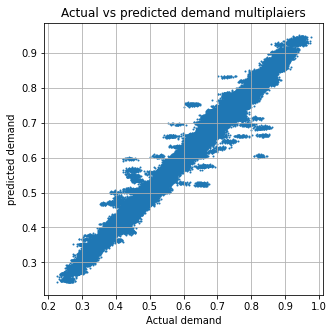

In [45]:
ax=plt.figure(1)
ax.set_figwidth(5)
ax.set_figheight(5)
plt.scatter(Y_test,y_pred,marker="o",s=1)
plt.grid()
plt.title("Actual vs predicted demand multiplaiers")
plt.xlabel("Actual demand")
plt.ylabel("predicted demand")
#plt.ylim(0,0.001)
#plt.legend()

plt.savefig('Multiplaier1_NN.png', dpi=300,bbox_inches='tight')
plt.show()

In [46]:
from sklearn.metrics import r2_score
s = r2_score(Y_test, y_pred)
s

0.9872989593470667

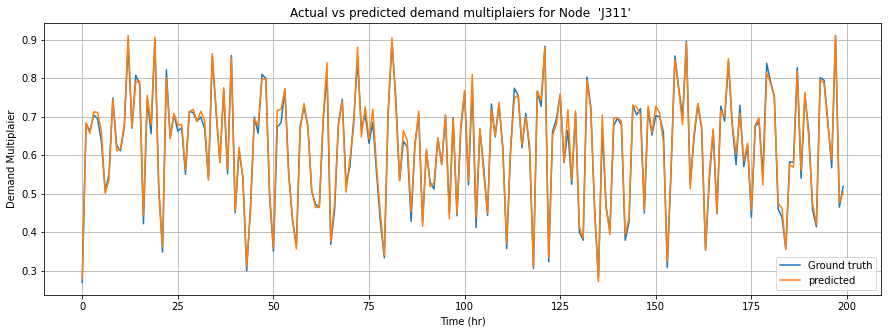

In [47]:
ax=plt.figure(1)
ax.set_figwidth(15)
ax.set_figheight(5)
plt.plot(Y_test[0:200,10],label="Ground truth")
plt.plot(y_pred[0:200,10],label="predicted")
plt.grid()
plt.title("Actual vs predicted demand multiplaiers for Node  'J311' ")
plt.xlabel("Time (hr)")
plt.ylabel("Demand Multiplaier")
#plt.ylim(0,0.001)
plt.legend()

plt.savefig('Multiplaier2_NN.png', dpi=300,bbox_inches='tight')
plt.show()

In [154]:
import eli5
from eli5.sklearn import PermutationImportance
#from sklearn.svm import SVC

# ... load data

#svc = SVC().fit(X_train, y_train)
perm = PermutationImportance(regr).fit(X_test, Y_test)
eli5.show_weights(perm)

Weight,Feature
0.0477 ± 0.0037,x389
0.0128 ± 0.0011,x594
0.0123 ± 0.0006,x593
0.0115 ± 0.0014,x826
0.0114 ± 0.0014,x697
0.0101 ± 0.0011,x591
0.0098 ± 0.0006,x592
0.0089 ± 0.0008,x694
0.0081 ± 0.0010,x394
0.0076 ± 0.0006,x392


In [157]:
eli5.show_weights(perm,top=100)

Weight,Feature
0.0477 ± 0.0037,x389
0.0128 ± 0.0011,x594
0.0123 ± 0.0006,x593
0.0115 ± 0.0014,x826
0.0114 ± 0.0014,x697
0.0101 ± 0.0011,x591
0.0098 ± 0.0006,x592
0.0089 ± 0.0008,x694
0.0081 ± 0.0010,x394
0.0076 ± 0.0006,x392


In [158]:
K_p.columns

Index(['J511', 'J411', 'J414', 'J415', 'J416', 'J417', 'J418', 'J419', 'J310',
       'J311',
       ...
       'PU1', 'PU2', 'PU4', 'PU7', 'PU8', 'PU10', 'v1', 'V45', 'V47', 'V2'],
      dtype='object', length=834)

In [178]:
num_list = np.linspace(0,834,835)

In [179]:
res = dict(zip(num_list,K_p.columns))
res

{0.0: 'J511',
 1.0: 'J411',
 2.0: 'J414',
 3.0: 'J415',
 4.0: 'J416',
 5.0: 'J417',
 6.0: 'J418',
 7.0: 'J419',
 8.0: 'J310',
 9.0: 'J311',
 10.0: 'J312',
 11.0: 'J313',
 12.0: 'J314',
 13.0: 'J315',
 14.0: 'J316',
 15.0: 'J318',
 16.0: 'J319',
 17.0: 'J210',
 18.0: 'J211',
 19.0: 'J212',
 20.0: 'J214',
 21.0: 'J217',
 22.0: 'J218',
 23.0: 'J219',
 24.0: 'J110',
 25.0: 'J420',
 26.0: 'J421',
 27.0: 'J422',
 28.0: 'J1153',
 29.0: 'J1154',
 30.0: 'J1155',
 31.0: 'J425',
 32.0: 'J426',
 33.0: 'J1157',
 34.0: 'J427',
 35.0: 'J1158',
 36.0: 'J428',
 37.0: 'J429',
 38.0: 'J320',
 39.0: 'J321',
 40.0: 'J322',
 41.0: 'J324',
 42.0: 'J1056',
 43.0: 'J327',
 44.0: 'J1058',
 45.0: 'J328',
 46.0: 'J329',
 47.0: 'J220',
 48.0: 'J221',
 49.0: 'J225',
 50.0: 'J226',
 51.0: 'J50',
 52.0: 'J51',
 53.0: 'J53',
 54.0: 'J54',
 55.0: 'J128',
 56.0: 'J55',
 57.0: 'J129',
 58.0: 'J56',
 59.0: 'J57',
 60.0: 'J58',
 61.0: 'J59',
 62.0: 'J1160',
 63.0: 'J1161',
 64.0: 'J431',
 65.0: 'J432',
 66.0: 'J433',
 67.0

In [180]:
num1 = pd.read_csv("sensor.csv")
num1 = np.array(num1.iloc[:,0])
num1

array([389, 594, 593, 826, 697, 591, 592, 694, 394, 392, 692, 691, 391,
       393, 698, 742, 667, 518, 610, 703, 684, 377, 827, 395,  71, 682,
       699, 695, 681, 704, 609, 642, 369, 705, 237,   7, 775, 311, 677,
       613, 688, 333, 533, 641, 696, 680, 607, 706, 606, 245, 825, 818,
       687, 539, 316, 502, 817, 325, 659, 390, 319, 130, 701, 464, 690,
       662, 101, 715, 105, 616, 331, 365, 668, 232, 439, 683, 327, 498,
       554, 746, 724, 332, 375, 625, 515, 621, 675, 801, 638, 819, 632,
       646, 605, 828, 716, 468, 702, 732, 499, 674], dtype=int64)

In [181]:
res[389.0]

'T3'

In [182]:
index1 = [res[key] for key in num1]
index1

['T3',
 'P378',
 'P376',
 'PU4',
 'P796',
 'P374',
 'P375',
 'P791',
 'T2',
 'T6',
 'P788',
 'P787',
 'T7',
 'T5',
 'P797',
 'P871',
 'P755',
 'P251',
 'P409',
 'P804',
 'P779',
 'J292',
 'PU7',
 'T4',
 'J1169',
 'P776',
 'P798',
 'P794',
 'P775',
 'P805',
 'P403',
 'P58',
 'J276',
 'P806',
 'J509',
 'J419',
 'P95',
 'J140',
 'P768',
 'P424',
 'P784',
 'J265',
 'P28',
 'P57',
 'P795',
 'P772',
 'P40',
 'P807',
 'P399',
 'J297',
 'PU2',
 'P994',
 'P783',
 'P287',
 'J170',
 'P230',
 'P993',
 'J216',
 'P70',
 'T1',
 'J184',
 'J350',
 'P800',
 'P147',
 'P786',
 'P724',
 'J1170',
 'P821',
 'J344',
 'P443',
 'J258',
 'J240',
 'P756',
 'J501',
 'P119',
 'P777',
 'J238',
 'P223',
 'P301',
 'P892',
 'P840',
 'J260',
 'J290',
 'P484',
 'P248',
 'P467',
 'P766',
 'P976',
 'P53',
 'P995',
 'P51',
 'P609',
 'P398',
 'PU8',
 'P822',
 'P154',
 'P801',
 'P851',
 'P225',
 'P763']

In [156]:
dataY=np.array([dataY])

np.shape(dataY)

(1, 334, 5376)

In [406]:
K_p = torch.tensor(K_p,dtype=torch.float)
#K2 = torch.tensor(K2,dtype=torch.float)
#K3 = torch.tensor(K3,dtype=torch.float)


ValueError: expected sequence of length 5376 at dim 0 (got 97)

In [ ]:
K_p.shape

In [ ]:
#e = torch.tensor(K1,dtype=torch.float)


In [ ]:
#e.shape

In [ ]:
dataY = torch.tensor(dataY,dtype=torch.float)

In [ ]:
ind11 = [16, 27, 26, 26, 14, 6, 7, 7, 1, 37, 37, 37, 11, 11, 25, 10, 10, 23, 4, 4, 4, 4, 4, 4, 35, 44, 44, 35, 35, 35, 44, 25, 30, 37, 33, 33, 38, 32, 0, 0, 0, 0, 0, 19, 0, 0, 0, 39, 39, 9, 9, 19, 19, 8, 18, 18, 13, 13, 13, 42, 42, 15, 18, 24, 24, 41, 3, 3, 3, 3, 3, 40, 40, 40, 40]

In [ ]:
ind22 = [27, 21, 21, 27, 26, 26, 14, 6, 43, 43, 1, 11, 28, 25, 10, 22, 23, 22, 10, 23, 22, 35, 44, 36, 44, 23, 22, 23, 22, 10, 10, 29, 29, 33, 34, 38, 32, 31, 7, 14, 26, 19, 2, 2, 20, 9, 8, 0, 9, 8, 2, 9, 8, 18, 13, 5, 5, 42, 15, 15, 5, 5, 24, 12, 41, 12, 24, 12, 41, 17, 40, 17, 12, 24, 41]

In [ ]:
edge_index=np.array([ind11,ind22])

In [ ]:
csv_url_ind="Adj_Mat_New.csv"
index = pd.read_csv(csv_url_ind)

index

In [ ]:
index = index.iloc[:,:2]

In [ ]:
index = np.array(index)
index

In [ ]:
index1  = torch.tensor(index.T,dtype=torch.long)
index1

In [ ]:
np.shape(index1)

In [ ]:
dataY.shape[1]

In [ ]:
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
data_list =[]

for i in range(dataY.shape[1]):
    data = Data(x=K_p[i], edge_index=index1, y=dataY[:,i])
    data_list.append(data)
#data_list = [Data(...), ..., Data(...)]
#loader = DataLoader(data_list, batch_size=32)

In [ ]:
data_list[2].num_features

In [ ]:
import torch
from torch.nn import Linear
import torch.nn.functional as F 
from torch_geometric.nn import GCNConv, TopKPooling, global_mean_pool,ChebConv
from torch_geometric.nn import global_mean_pool as gap, global_max_pool as gmp
embedding_size = 128
#normalization='rw'
class GCN(torch.nn.Module):
    def __init__(self):
        # Init parent
        super(GCN, self).__init__()
        torch.manual_seed(42)

        # GCN layers
        self.initial_conv = ChebConv(data.num_features, embedding_size,2)
        self.conv1 = ChebConv(embedding_size, embedding_size,2)
        #self.conv2 = ChebConv(embedding_size, embedding_size,2)
        #self.conv3 = GCNConv(embedding_size, embedding_size)

        # Output layer
        #self.out1 = Linear(embedding_size*2, embedding_size*2)
        self.out2 = Linear(embedding_size*2, embedding_size*2)
        self.out3 = Linear(embedding_size*2, 1)

    def forward(self, x, edge_index, batch_index):
        # First Conv layer
        hidden = self.initial_conv(x, edge_index)
        hidden = F.relu(hidden)

        # Other Conv layers
        hidden = self.conv1(hidden, edge_index)
        hidden = F.relu(hidden)
        #hidden = self.conv2(hidden, edge_index,edge_weight)
        #hidden = F.relu(hidden)
        #hidden = self.conv3(hidden, edge_index,edge_weight)
        #hidden = F.relu(hidden)
          
        # Global Pooling (stack different aggregations)
        hidden = torch.cat([gmp(hidden, batch_index), gap(hidden, batch_index)], dim=1)

        # Apply a final (linear) classifier.
        #hidden = self.out1(hidden)
        #hidden = F.relu(hidden)
        hidden = self.out2(hidden)
        hidden = F.relu(hidden)
        hidden = self.out3(hidden)
        

        return hidden

model = GCN()
print(model)
print("Number of parameters: ", sum(p.numel() for p in model.parameters()))

#ChebConv(in_channels: int, out_channels: int, K: int, normalization: Optional[str] = 'sym', bias: bool = True, **kwargs)

In [ ]:
from torch_geometric.data import DataLoader
import warnings
warnings.filterwarnings("ignore")

# Root mean squared error
loss_fn = torch.nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)  

# Use GPU for training
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# Wrap data in a data loader
data_size = len(data_list)
NUM_GRAPHS_PER_BATCH = 512
loader = DataLoader(data_list[:int(data_size * 0.8)], 
                    batch_size=NUM_GRAPHS_PER_BATCH, shuffle=True)
test_loader = DataLoader(data_list[int(data_size * 0.8):], 
                         batch_size=NUM_GRAPHS_PER_BATCH, shuffle=True)

def train(data):
    # Enumerate over the data
    for batch in loader:
      # Use GPU
      batch.to(device)  
      # Reset gradients
      optimizer.zero_grad() 
      # Passing the node features and the connection info
      pred = model(batch.x.float(), batch.edge_index, batch.batch) 
      # Calculating the loss and gradients
      loss = loss_fn(pred, batch.y)     
      loss.backward()  
      # Update using the gradients
      optimizer.step()   
    return loss

print("Starting training...")
losses = []
for epoch in range(3000):
    loss = train(data_list)
    losses.append(loss)
    if epoch % 20 == 0:
      print(f"Epoch {epoch} | Train Loss {loss}")

In [ ]:
# # Visualize learning (training loss)
import seaborn as sns
import matplotlib.pyplot as plt
losses_float = [float(loss.cpu().detach().numpy()) for loss in losses] 
loss_indices = [i for i,l in enumerate(losses_float)] 
plt1 = plt.plot(loss_indices, losses_float)
plt.show()

In [ ]:
import pandas as pd 

# Analyze the results for one batch
test_batch = next(iter(test_loader))
with torch.no_grad():
    test_batch.to(device)
    pred = model(test_batch.x.float(), test_batch.edge_index, test_batch.batch) 
    df = pd.DataFrame()
    df["y_real"] = test_batch.y.tolist()
    df["y_pred"] = pred.tolist()


In [ ]:
test_batch.y

In [ ]:
df["y_real"] = df["y_real"].apply(lambda row: row[0])
df["y_pred"] = df["y_pred"].apply(lambda row: row[0])
df.head(12)

In [ ]:
plt = sns.scatterplot(data=df, x="y_real", y="y_pred")
plt

In [ ]:
from sklearn.metrics import r2_score
                                     
R2 = r2_score(df.iloc[:,0], df.iloc[:,1])   

R2
                                     

In [ ]:
#torch.save(model.state_dict(),'C:\\Users\\ADMIN\\OneDrive - Indian Institute of Technology Bombay\\Project Codes\\CTown\\MultiplayerGCN\\Chebnet3Pressure_flow.pth')

